In [1]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
det_df = pd.read_csv(
    r"C:\Users\bhanu\Downloads\StructCompose\data\annotations\sample_subjects.csv"
)

det_df

,class,confidence,x1,y1,x2,y2,center_x,center_y,area,thirds_distance,visual_weight
0,person,0.851322,121.10225,58.31953,504.31744,1015.34705,312.70984,536.83330,366747.500,164.16148,0.428234
1,person,0.805063,0.00000,285.32013,167.70773,909.53955,83.85387,597.42980,104686.420,175.55988,0.115595
2,person,0.607115,623.24110,272.96558,705.88820,415.89096,664.56464,344.42828,11812.368,189.92320,0.009836
3,person,0.595085,40.05102,211.72372,141.34187,413.16522,90.69645,312.44446,20404.180,149.45547,0.016654
4,person,0.292444,290.02765,149.40817,518.80927,479.85150,404.41846,314.62982,75599.360,75.15243,0.030324


In [3]:
G = nx.Graph()

In [4]:
for idx, row in det_df.iterrows():

    G.add_node(

        idx,

        label=row["class"],

        center_x=row["center_x"],
        center_y=row["center_y"],

        area=row["area"],

        visual_weight=row["visual_weight"],

        thirds_distance=row["thirds_distance"]

    )

In [5]:
G.nodes(data=True)

NodeDataView({0: {'label': 'person', 'center_x': 312.70984, 'center_y': 536.8333, 'area': 366747.5, 'visual_weight': 0.42823395, 'thirds_distance': 164.16148}, 1: {'label': 'person', 'center_x': 83.85387, 'center_y': 597.4298, 'area': 104686.42, 'visual_weight': 0.11559529, 'thirds_distance': 175.55988}, 2: {'label': 'person', 'center_x': 664.56464, 'center_y': 344.42828, 'area': 11812.368, 'visual_weight': 0.009836214, 'thirds_distance': 189.9232}, 3: {'label': 'person', 'center_x': 90.69645, 'center_y': 312.44446, 'area': 20404.18, 'visual_weight': 0.016653998, 'thirds_distance': 149.45547}, 4: {'label': 'person', 'center_x': 404.41846, 'center_y': 314.62982, 'area': 75599.36, 'visual_weight': 0.030323602, 'thirds_distance': 75.15243}})

In [6]:
nodes = list(G.nodes())

for i in range(len(nodes)):

    for j in range(i + 1, len(nodes)):

        n1 = G.nodes[nodes[i]]
        n2 = G.nodes[nodes[j]]

        dx = n1["center_x"] - n2["center_x"]
        dy = n1["center_y"] - n2["center_y"]

        distance = np.sqrt(dx**2 + dy**2)

        G.add_edge(
            nodes[i],
            nodes[j],

            distance=distance
        )

In [7]:
for u, v, data in G.edges(data=True):

    w1 = G.nodes[u]["visual_weight"]
    w2 = G.nodes[v]["visual_weight"]

    balance = 1 - abs(w1 - w2)

    data["balance"] = balance

In [9]:
for u, v, data in G.edges(data=True):

    distance = data["distance"]

    w1 = G.nodes[u]["visual_weight"]
    w2 = G.nodes[v]["visual_weight"]

    tension = (
        (w1 + w2)
        /
        (distance + 1)
    )

    data["tension"] = tension

In [10]:
G.edges(data=True)

EdgeDataView([(0, 1, {'distance': np.float64(236.74245672648345), 'balance': 0.68736134, 'tension': np.float64(0.0022874721136816613)}), (0, 2, {'distance': np.float64(401.0255503134937), 'balance': 0.581602264, 'tension': np.float64(0.001089657519673561)}), (0, 3, {'distance': np.float64(315.65851304192273), 'balance': 0.588420048, 'tension': np.float64(0.0014049454844155755)}), (0, 4, {'distance': np.float64(240.38481130557065), 'balance': 0.6020896520000001, 'tension': np.float64(0.0018996951362424742)}), (1, 2, {'distance': np.float64(633.4309492883209), 'balance': 0.894240924, 'tension': np.float64(0.00019770710136493815)}), (1, 3, {'distance': np.float64(285.0674743213824), 'balance': 0.901058708, 'tension': np.float64(0.0004623010299011644)}), (1, 4, {'distance': np.float64(427.4780521265021), 'balance': 0.914728312, 'tension': np.float64(0.0003405516134976255)}), (2, 3, {'distance': np.float64(574.7587878716328), 'balance': 0.993182216, 'tension': np.float64(4.600921871800605e-

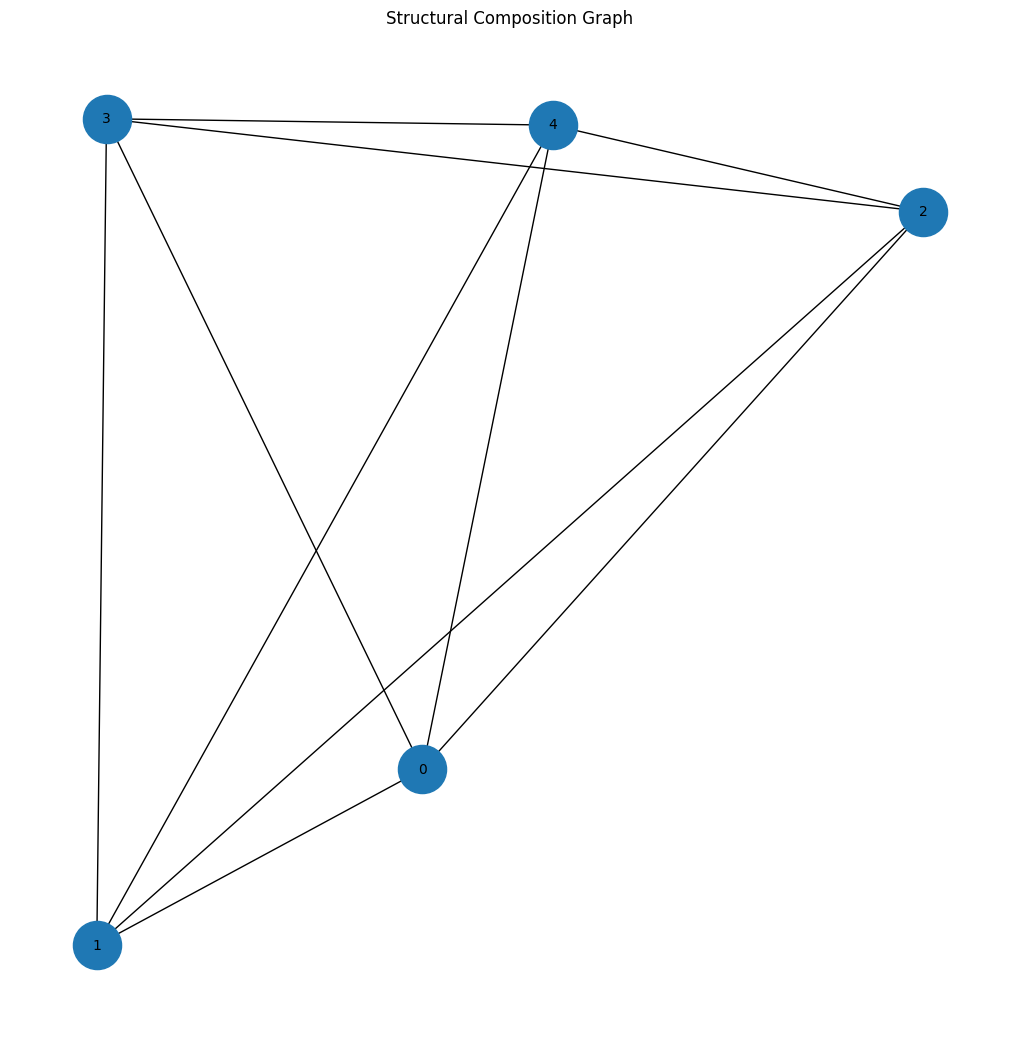

In [11]:
pos = {}

for node in G.nodes():

    x = G.nodes[node]["center_x"]
    y = -G.nodes[node]["center_y"]

    pos[node] = (x, y)

plt.figure(figsize=(10,10))

nx.draw(

    G,
    pos,

    with_labels=True,

    node_size=1200,

    font_size=10

)

plt.title("Structural Composition Graph")

plt.show()

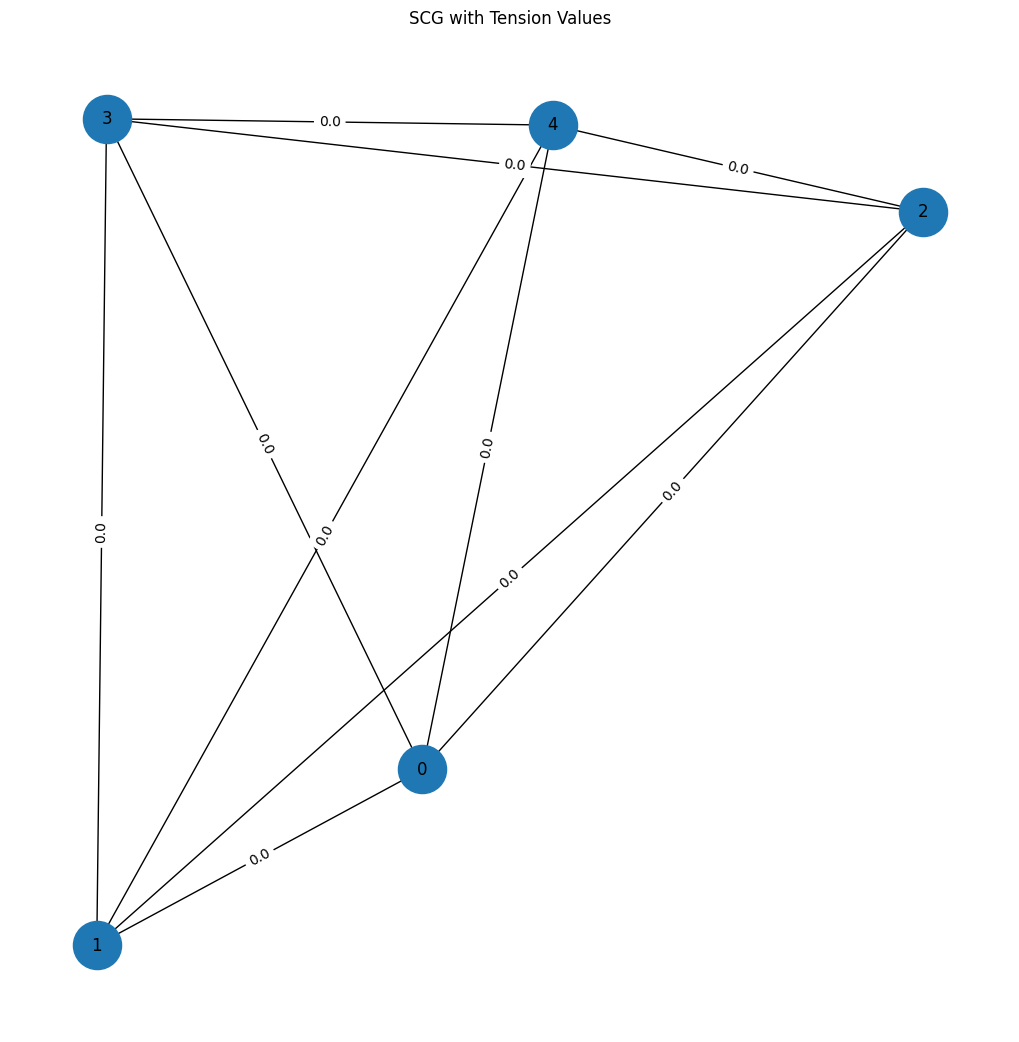

In [12]:
edge_labels = {}

for u, v, data in G.edges(data=True):

    edge_labels[(u,v)] = round(data["tension"], 2)

plt.figure(figsize=(10,10))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("SCG with Tension Values")

plt.show()

In [15]:
graph_data = nx.node_link_data(G)

save_path = r"C:\Users\bhanu\Downloads\StructCompose\data\graphs\sample_scg.json"

with open(save_path, "w") as f:

    json.dump(graph_data, f)

print("SCG saved")

SCG saved
